In [ ]:
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.layers import Dense,Flatten, Input, Dropout


In [ ]:
# code
"""
Kaggle API setup
Credits: ://www.kaggle.com/general/74235https
"""
# Install Kaggle module
!pip install kaggle

# Upload API details json file to colab
from google.colab import files
files.upload()
# create a Kaggle directory and move json files to there
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
# change permissions of kaggle json file
! chmod 600 ~/.kaggle/kaggle.json
# Now we download our dataset with following command format :
"""
! kaggle datasets download -d user/dataset
or
! kaggle competitions download -c 'name-of-competition'
"""
! kaggle datasets download -d tawsifurrahman/covid19-radiography-database


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
 96% 750M/778M [00:10<00:01, 18.0MB/s]
100% 778M/778M [00:10<00:00, 77.5MB/s]


In [ ]:
! unzip covid19-radiography-database.zip -d /content/data


Streaming output truncated to the last 5000 lines.
  inflating: /content/data/COVID-19_Radiography_Dataset/Normal/masks/Normal-7921.png  
  inflating: /content/data/COVID-19_Radiography_Dataset/Normal/masks/Normal-7922.png  
  inflating: /content/data/COVID-19_Radiography_Dataset/Normal/masks/Normal-7923.png  
  inflating: /content/data/COVID-19_Radiography_Dataset/Normal/masks/Normal-7924.png  
  inflating: /content/data/COVID-19_Radiography_Dataset/Normal/masks/Normal-7925.png  
  inflating: /content/data/COVID-19_Radiography_Dataset/Normal/masks/Normal-7926.png  
  inflating: /content/data/COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png  
  inflating: /content/data/COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png  
  inflating: /content/data/COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png  
  inflating: /content/data/COVID-19_Radiography_Dataset/Normal/masks/Normal-793.png  
  inflating: /content/data/COVID-19_Radiography_Dataset/Normal/masks/Normal-7930

In [ ]:
# Load Xception model
base = Xception(weights="imagenet", input_shape =(299,299,3),include_top= False)
# set base model trainable to false
for layers in base.layers:
	layers.trainable=False

base.summary()


83683744/83683744 [==============================] - 0s 0us/step
Model: "xception"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 299, 299, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 149, 149, 32)         864       ['input_1[0][0]']             
                                                                                                  
 block1_conv1_bn (BatchNorm  (None, 149, 149, 32)         128       ['block1_conv1[0][0]']        
 alization)                                                                                       
                                                                                                  
 block1_conv1_act (Activat

Found 31748 images belonging to 1 classes.
Found 10582 images belonging to 1 classes.


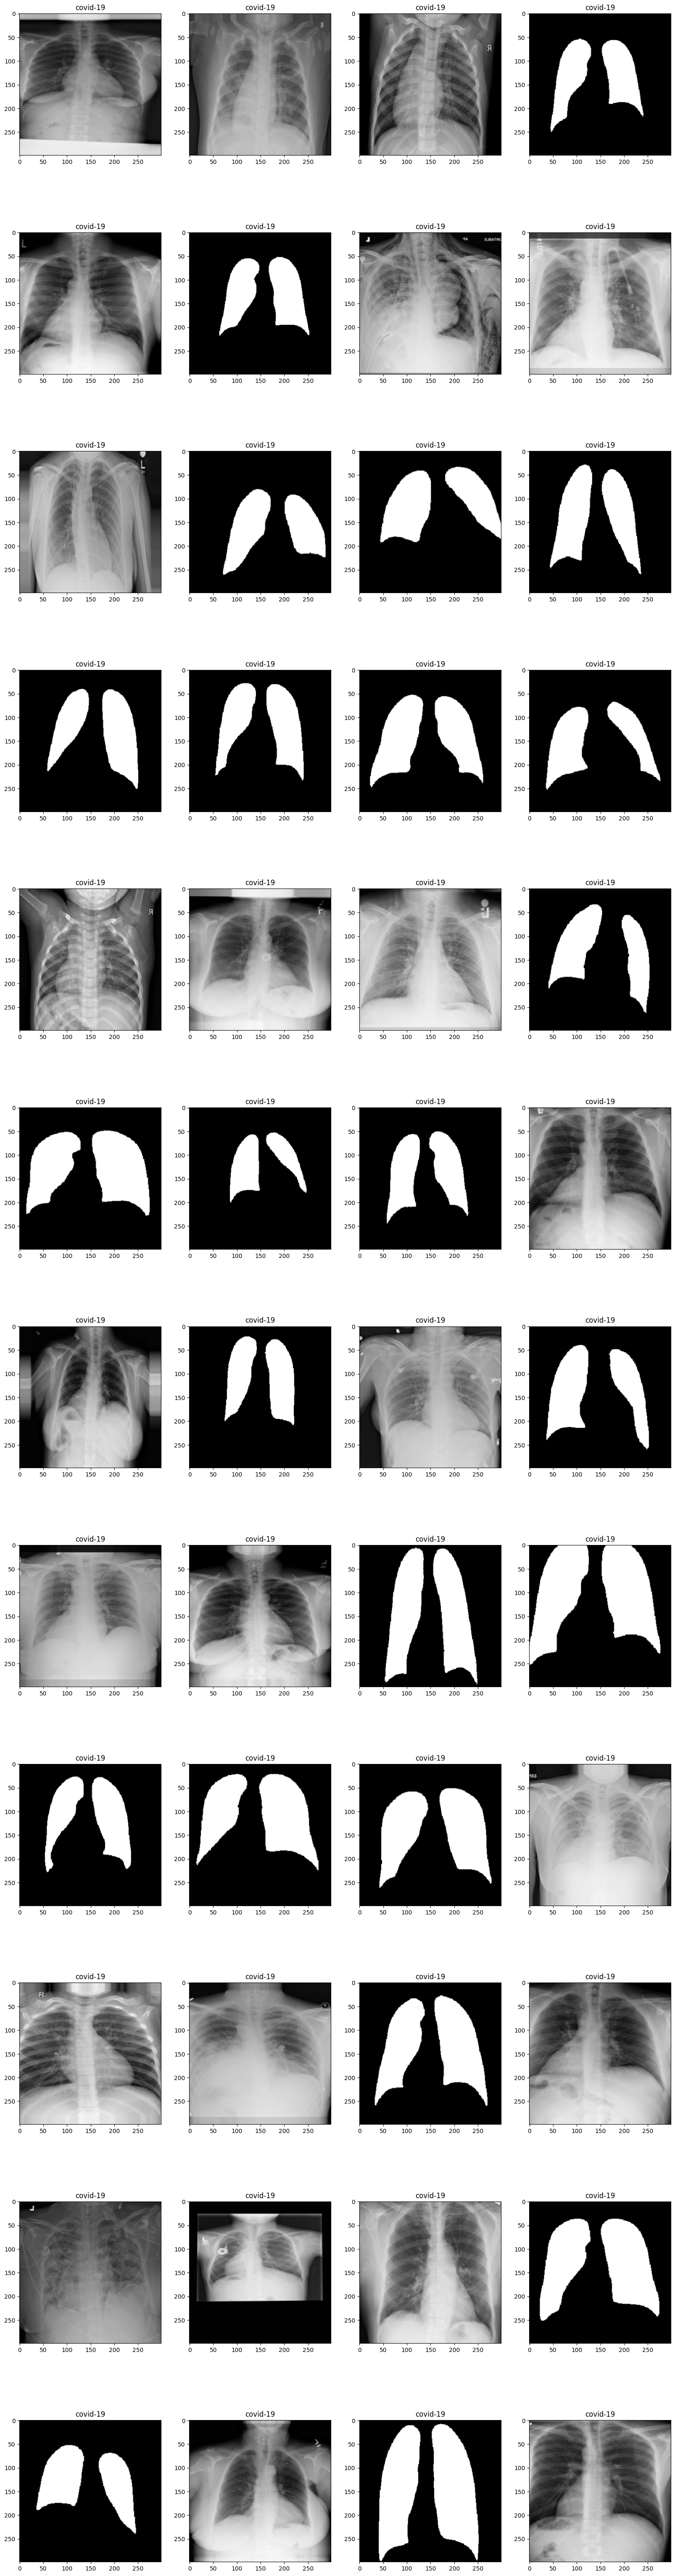

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing.image import ImageDataGenerator

# Define the batch size
batch_size = 16

# Define augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    validation_split=0.25,
    horizontal_flip=True
)

# Apply augmentations on dataset
train = train_datagen.flow_from_directory(
    "data/",
    target_size=(299, 299),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)
val = train_datagen.flow_from_directory(
    "data/",
    target_size=(299, 299),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

class_names = ['covid-19', 'normal', 'pneumonia']

# Code to plot images
def plotImages(images_arr, labels):
    fig, axes = plt.subplots(12, 4, figsize=(20, 80))
    axes = axes.flatten()
    label = 0
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
        ax.set_title(class_names[np.argmax(labels[label])])
        label = label + 1
    plt.show()

# Append a batch of images from each category (COVID-19, Normal, Pneumonia)
images = [train[34][0][i] for i in range(16)]
images += [train[5][0][i] for i in range(16)]
images += [train[0][0][i] for i in range(16)]

# Append the batch of labels
labels = [train[34][1][i] for i in range(16)]
labels += [train[5][1][i] for i in range(16)]
labels += [train[0][1][i] for i in range(16)]

# Plot images with labels
plotImages(images, labels)


In [ ]:
# Define our complete models
model = Sequential()
model.add(Input(shape =(299,299,3)))
model.add(base)
model.add(Dropout(0.2))
model.add(Flatten())
model.add(Dropout(0.2))
model.add(Dense(16))
model.add(Dense(3,activation='softmax'))
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 xception (Functional)       (None, 10, 10, 2048)      20861480  
                                                                 
 dropout (Dropout)           (None, 10, 10, 2048)      0         
                                                                 
 flatten (Flatten)           (None, 204800)            0         
                                                                 
 dropout_1 (Dropout)         (None, 204800)            0         
                                                                 
 dense (Dense)               (None, 16)                3276816   
                                                                 
 dense_1 (Dense)             (None, 3)                 51        
                                                                 
Total params: 24138347 (92.08 MB)
Trainable params: 3276

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the model (define metrics and loss)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model for 30 epochs
model.fit(
    train,
    epochs=5,
    validation_data=val
)

# Save the model
model.save('covid19.h5')


Epoch 1/5
1985/1985 [==============================] - 983s 492ms/step - loss: 527.7622 - accuracy: 0.4375 - val_loss: 1162.2507 - val_accuracy: 0.3278
Epoch 2/5
1985/1985 [==============================] - 937s 472ms/step - loss: 1347.3950 - accuracy: 0.3746 - val_loss: 1778.2211 - val_accuracy: 0.2727
Epoch 3/5
1985/1985 [==============================] - 935s 471ms/step - loss: 1808.8662 - accuracy: 0.3555 - val_loss: 1951.3196 - val_accuracy: 0.1863
Epoch 4/5
1985/1985 [==============================] - 937s 472ms/step - loss: 2079.3914 - accuracy: 0.3429 - val_loss: 2445.0029 - val_accuracy: 0.0931
Epoch 5/5
1985/1985 [==============================] - 921s 464ms/step - loss: 2250.7148 - accuracy: 0.3329 - val_loss: 3200.7859 - val_accuracy: 0.0221


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# prompt: test with new image  from drive

import cv2

# Load the saved model
model = tf.keras.models.load_model('/content/drive/MyDrive/pnemoniacha.h5')

# Load the image from drive
image_path = '/content/drive/MyDrive/image.jpg'
img = cv2.imread(image_path)

# Preprocess the image
img = cv2.resize(img, (299, 299))
img = img / 255.0

# Make a prediction
prediction = model.predict(np.expand_dims(img, axis=0))

# Get the predicted class
predicted_class = np.argmax(prediction)

# Print the predicted class
print("Predicted class:", class_names[predicted_class])


In [ ]:
# prompt: test with new image  from drive

import cv2

# Load the image from drive
image_path = '/content/drive/MyDrive/anuja/normalized/1.png'
img = cv2.imread(image_path)

# Preprocess the image
img = cv2.resize(img, (299, 299))
img = img / 255.0

# Make a prediction
prediction = model.predict(np.expand_dims(img, axis=0))

# Get the predicted class
predicted_class = np.argmax(prediction)

# Print the predicted class
print("Predicted class:", class_names[predicted_class])

In [ ]:
pip install numpy pandas scikit-learn tensorflow


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create a synthetic dataset
data = {
    'Feature1': np.random.rand(10),
    'Feature2': np.random.rand(10),
    'Feature3': np.random.rand(10),
    'Label': np.random.randint(0, 2, 10)
}
df = pd.DataFrame(data)

# Separate features and labels
X = df.drop('Label', axis=1).values
y = df['Label'].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the neural network model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=1, validation_split=0.2)

# Evaluate the model on the test set
y_pred = (model.predict(X_test) > 0.5).astype("int32")
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy * 100))
print(classification_report(y_test, y_pred))


Epoch 1/50
6/6 [==============================] - 6s 82ms/step - loss: 0.8416 - accuracy: 0.3333 - val_loss: 0.4311 - val_accuracy: 1.0000
Epoch 2/50
6/6 [==============================] - 0s 19ms/step - loss: 0.7896 - accuracy: 0.3333 - val_loss: 0.4554 - val_accuracy: 1.0000
Epoch 3/50
6/6 [==============================] - 0s 19ms/step - loss: 0.7565 - accuracy: 0.3333 - val_loss: 0.4899 - val_accuracy: 1.0000
Epoch 4/50
6/6 [==============================] - 0s 20ms/step - loss: 0.7119 - accuracy: 0.3333 - val_loss: 0.5079 - val_accuracy: 1.0000
Epoch 5/50
6/6 [==============================] - 0s 16ms/step - loss: 0.6681 - accuracy: 0.3333 - val_loss: 0.5257 - val_accuracy: 1.0000
Epoch 6/50
6/6 [==============================] - 0s 30ms/step - loss: 0.6401 - accuracy: 0.5000 - val_loss: 0.5491 - val_accuracy: 0.5000
Epoch 7/50
6/6 [==============================] - 0s 12ms/step - loss: 0.6127 - accuracy: 0.8333 - val_loss: 0.5593 - val_accuracy: 0.5000
Epoch 8/50
6/6 [===========

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
